# 6. RBC Model in Python

The algorithm is the same as that we ues in MATLAB case.

## Import Module

In [1]:
# !pip install autograd  # if you use autograd for the first time
import autograd.numpy as np
import math
from autograd import jacobian
np.set_printoptions(suppress=True,precision=4)

__import autograd.numpy as np__: This imports the numpy library but uses Autograd's version, which allows for automatic differentiation. This is useful for optimization and sensitivity analysis.

__np.set_printoptions(suppress=True, precision=4)__: This sets the printing options for NumPy arrays, suppressing scientific notation and limiting the precision of printed numbers to 4 decimal places.

## Indexing

In [2]:
nX = 8
nEps = 1
iA, iR, iN, iK, iY, iC, iI, iW = range(nX)

__nX = 8__: This defines the number of state variables in the model (5 in this case).

__nEps = 1__: This defines the number of shocks (1 in this case).

__iA, iR, iN, iK, iY, iC, iI, iW = range(nX)__: This creates indices for the state variables:

iA (technology level), iR (interest rate), iN (working hour), iK (capital), iY (output), iC (consumption), iI (investment), iW (wage).

## Parameters

In [3]:
alpha = 0.35    # capital share
beta = 0.99     # discount factor
gamma = 1       # risk aversion
eta = 1         # labor elasticity
delta = 0.025   # depreciation rate
rho = 0.95      # TFP persistency
phi = 7.8       # labor disutility

Model parameters are defined:

    alpha: Output elasticity of capital.
    beta: Discount factor for future utility.
    gamma: Coefficient of relative risk aversion.
    delta: Depreciation rate of capital.
    rho: Persistence of technology shocks.

In [4]:
def SteadyState():
    A = 1
    R = 1 / beta - 1 + delta
    N = 1/3
    K = N * (R/A/alpha)**(1/(alpha-1))
    Y = A * K**alpha * N**(1-alpha)
    C = Y - delta * K
    I = delta*K
    W = (1-alpha)*Y/N

    X = np.zeros(nX)
    X[[iA, iR, iN, iK, iY, iC, iI, iW]] = (A, R, N, K, Y, C, I, W)
    return X

__def SteadyState()__: This defines a function to calculate the steady state of the model.

__A = 1.__: Sets the technology level (Z) to 1.

__R = 1 / beta - 1 + delta__: Calculates the steady-state interest rate.

__K = N * (R/A/alpha)^(1/(alpha-1))__: Calculates the steady-state capital stock using the given parameters.

__Y = A * K^alpha * N^(1-alpha)__: Calculates output (Y) using the Cobb-Douglas production function.

__C = Y - delta * K__: Calculates consumption (C) as the output minus depreciation on capital.

__X = np.zeros(nX)__: Initializes a vector X of zeros to store state variables.

__X[[iA, iR, iN, iK, iY, iC, iI, iW]] = (A, R, N, K, Y, C, I, W)__: Assigns the calculated values to the corresponding indices in X.

In [5]:
X_SS = SteadyState()
epsilon_SS = 0.0
print("Steady state: {}".format(X_SS))

Steady state: [ 1.      0.0351  0.3333 11.4661  1.1499  0.8633  0.2867  2.2423]


__X_SS = SteadyState()__: Calls the SteadyState function and stores the result in X_SS.

__epsilon_SS = 0.0__: Initializes the steady-state value of the shock to zero.

## Model equations

In [6]:

def F(X_Lag, X, X_Prime, epsilon):

    # Unpack. The state variables are unpacked from the input vectors X_Lag, X, and X_Prime.
    A, R, N, K, Y, C, I, W = X
    A_L, R_L, N_L, K_L, Y_L, C_L, I_L, W_L = X_Lag
    A_P, R_P, N_P, K_P, Y_P, C_P, I_P, W_P = X_Prime

    return np.hstack((
        beta * (1+R-delta) * C_P**(-1/gamma) * C**(1/gamma) - 1.0, # Euler equation
        phi * N**(1/eta) - W*C**(-1/gamma),   
        A * K_L**alpha * N**(1-alpha) - Y, # Production function
        alpha * A * K_L**(alpha-1) * N**(1-alpha) - R, # MPK
        (1-alpha) * A * K_L**alpha * N**(-alpha) - W, # MPN
        (1 - delta) * K_L + I_L - K, # Aggregate resource constraint 
        # Do not use (1 - delta) * K + I - K_P
        Y - C - I, # Aggregate resource constraint
        rho * np.log(A_L) + epsilon - np.log(A) # TFP evolution
        ))

To calculate power result, we use ^ in MATLAB, and use ** in Python.

And to calculate log, we directly use log in MATLAB, and use np.log in Python.

__def F(X_Lag, X, X_Prime, epsilon)__: Defines a function F that contains the model equations.

Returns a stacked array with the 8 equations we discussed above.
   
__numpy.hstack()__ function is used to stack the sequence of input arrays horizontally (i.e. column wise) to make a single array.

## Check steady state

When we select a proper $\phi$, we should get an array consists of zeros, or close to zero.

In [7]:
 F(X_SS,X_SS,X_SS,epsilon_SS)

array([0.    , 0.0025, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ])

## Linearize

In [8]:
A = jacobian(lambda x: F(X_SS,X_SS,x,epsilon_SS))(X_SS)
B = jacobian(lambda x: F(X_SS,x,X_SS,epsilon_SS))(X_SS)
C = jacobian(lambda x: F(x,X_SS,X_SS,epsilon_SS))(X_SS)
E = jacobian(lambda x: F(X_SS,X_SS,X_SS,x))(epsilon_SS)

print("A: {}".format(A))
print("B: {}".format(B))
print("C: {}".format(C))
print("E: {}".format(E))

A: [[ 0.      0.      0.      0.      0.     -1.1584  0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.      0.      0.    ]]
B: [[ 0.      0.99    0.      0.      0.      1.1584  0.      0.    ]
 [ 0.      0.      7.8     0.      0.      3.0089  0.     -1.1584]
 [ 1.1499  0.      2.2423  0.     -1.      0.      0.      0.    ]
 [ 0.0351 -1.      0.0684  0.      0.      0.      0.      0.    ]
 [ 2.2423  0.     -2.3545  0.      0.      0.      0.     -1.    ]
 [ 0.      0.      0.     -1.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      1.     -1.     -1.  

Calculate the Jacobian matrices for the model equations, which represent how the system responds to small changes in state variables.

The last __(X_SS)__ means evaluating the Jacobian at the point X_SS.

A: How small change of future variables affect the system equilibrium, starting ananlysis from X_SS.

B: How nowadays affect the system.

C: How past affect the system.

E: How exogenous shock affect the system, starting analysis from epsilon_SS.

In [9]:
def SolveSystem(A,B,C,E):
    # Solve the system using linear time iteration as in Rendahl (2017)    
    MAXIT = 1000    
    P = np.zeros(A.shape)  

    for it in range(MAXIT):
        P = -np.linalg.lstsq(B+A@P,C,rcond=None)[0]   # (B+A⋅P)⋅(-P)=C        
        test = np.max(np.abs(C+B@P+A@P@P))        # C+B*P+A*P*P=0
        if test < 1e-7:
            break

    # Impact matrix
    #  Solution is x_{t}=P*x_{t-1}+Q*eps_t
    Q = -np.linalg.inv(B+A@P) @ E    # Q = - E*(B+AP)

    return P, Q

In [10]:
P, Q = SolveSystem(A,B,C,E)
print(P)
print(Q)

[[ 0.95   -0.     -0.     -0.     -0.     -0.     -0.     -0.    ]
 [ 0.0444 -0.     -0.     -0.0023 -0.     -0.     -0.0008 -0.    ]
 [ 0.1614 -0.     -0.     -0.0052 -0.     -0.     -0.0121 -0.    ]
 [ 0.     -0.     -0.      0.975  -0.     -0.      1.     -0.    ]
 [ 1.4543 -0.     -0.      0.0235 -0.     -0.     -0.0271 -0.    ]
 [ 0.2554 -0.     -0.      0.0445 -0.     -0.      0.0423 -0.    ]
 [ 1.1989 -0.     -0.     -0.0211 -0.     -0.     -0.0694 -0.    ]
 [ 1.7502 -0.     -0.      0.0807 -0.     -0.      0.0285 -0.    ]]
[1.     0.0467 0.1699 0.     1.5309 0.2689 1.262  1.8423]


Calls a function __SolveSystem__ to solve the linearized system of equations, returning matrices P and Q.

## Calculate an impulse response

In [11]:
IRF_RBC = np.zeros((nX,100))
IRF_RBC[:,0] = Q * 0.01

for t in range(1,100):
    IRF_RBC[:,t] = P@IRF_RBC[:,t-1]

__IRF_RBC = np.zeros((nX, 100))__: Initializes a matrix to store impulse response functions.

__IRF_RBC[:, 0] = Q * 0.01__: Sets the initial impulse response based on matrix Q.

Loop: Iteratively calculates the impulse responses for 100 periods using the transition matrix P.

In Python, the @ operator is used for matrix multiplication. To convert this line to MATLAB, you will use the * operator instead

## Print

Finally, we plot the impulse response function, which is the same as what we get in MATLAB and Dynare.

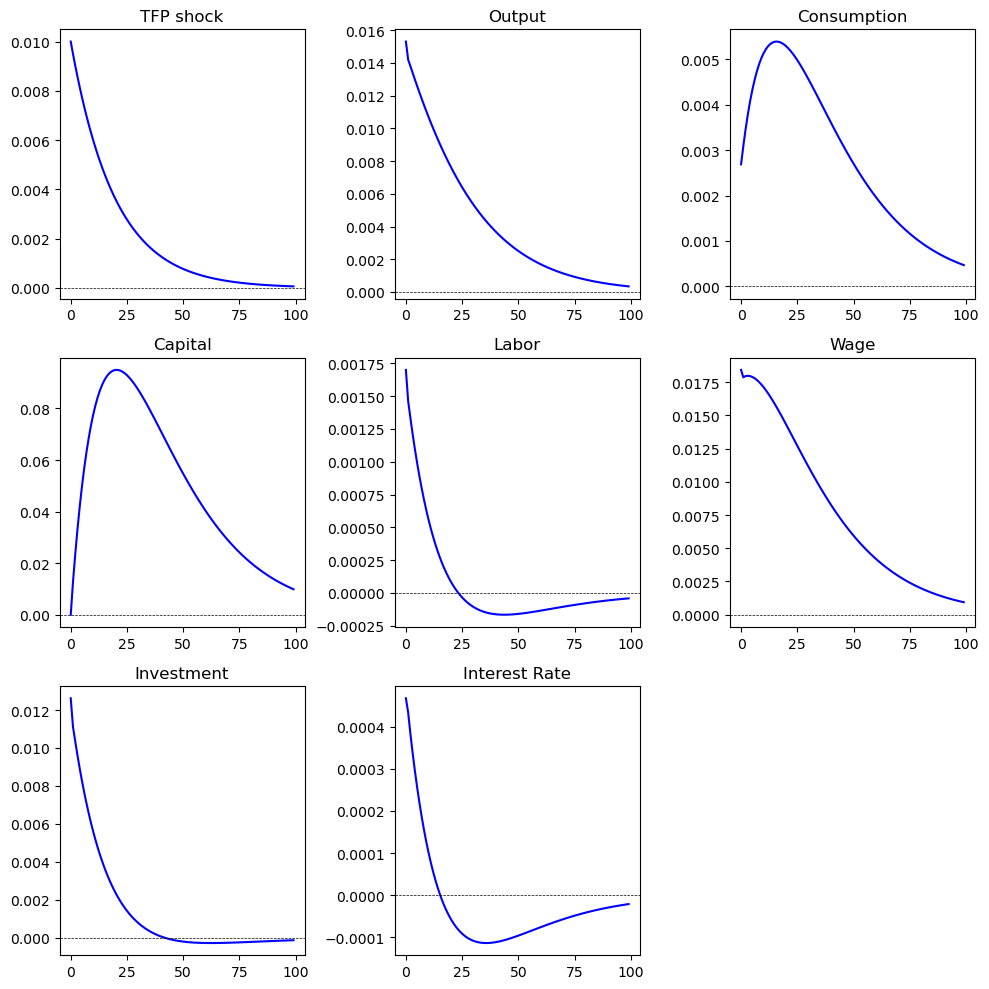

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# create a 3x3 subplot
fig, axs = plt.subplots(3, 3, figsize=(10, 10))

# subplot
axs[0, 0].plot(IRF_RBC[iA, :], label='Impulse Response of Output', color='blue')
axs[0, 0].set_title('TFP shock')
axs[0, 0].axhline(0, color='black', lw=0.5, ls='--') 
# axs[0, 0].legend()

axs[0, 1].plot(IRF_RBC[iY, :], label='Impulse Response of Output', color='blue')
axs[0, 1].set_title('Output')
axs[0, 1].axhline(0, color='black', lw=0.5, ls='--') 

axs[0, 2].plot(IRF_RBC[iC, :], label='Impulse Response of Output', color='blue')
axs[0, 2].set_title('Consumption')
axs[0, 2].axhline(0, color='black', lw=0.5, ls='--') 

axs[1, 0].plot(IRF_RBC[iK, :], label='Impulse Response of Output', color='blue')
axs[1, 0].set_title('Capital')
axs[1, 0].axhline(0, color='black', lw=0.5, ls='--') 

axs[1, 1].plot(IRF_RBC[iN, :], label='Impulse Response of Output', color='blue')
axs[1, 1].set_title('Labor')
axs[1, 1].axhline(0, color='black', lw=0.5, ls='--') 

axs[1, 2].plot(IRF_RBC[iW, :], label='Impulse Response of Output', color='blue')
axs[1, 2].set_title('Wage')
axs[1, 2].axhline(0, color='black', lw=0.5, ls='--') 

axs[2, 0].plot(IRF_RBC[iI, :], label='Impulse Response of Output', color='blue')
axs[2, 0].set_title('Investment')
axs[2, 0].axhline(0, color='black', lw=0.5, ls='--') 

axs[2, 1].plot(IRF_RBC[iR, :], label='Impulse Response of Output', color='blue')
axs[2, 1].set_title('Interest Rate')
axs[2, 1].axhline(0, color='black', lw=0.5, ls='--') 

axs[2, 2].axis('off')

# layout adjustment 
plt.tight_layout()
plt.show()